In [1]:
!pip -q install umap-learn

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_swiss_roll
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

In [3]:
# Generar datos
X, t = make_swiss_roll(n_samples=2000, noise=0.05, random_state=42)

In [4]:
X_pca = PCA(n_components=2).fit_transform(X)

In [5]:
X_tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=42
).fit_transform(X)


In [6]:
X_umap = umap.UMAP(
    n_components=2,
    n_neighbors=20,
    min_dist=0.1,
    random_state=42
).fit_transform(X)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


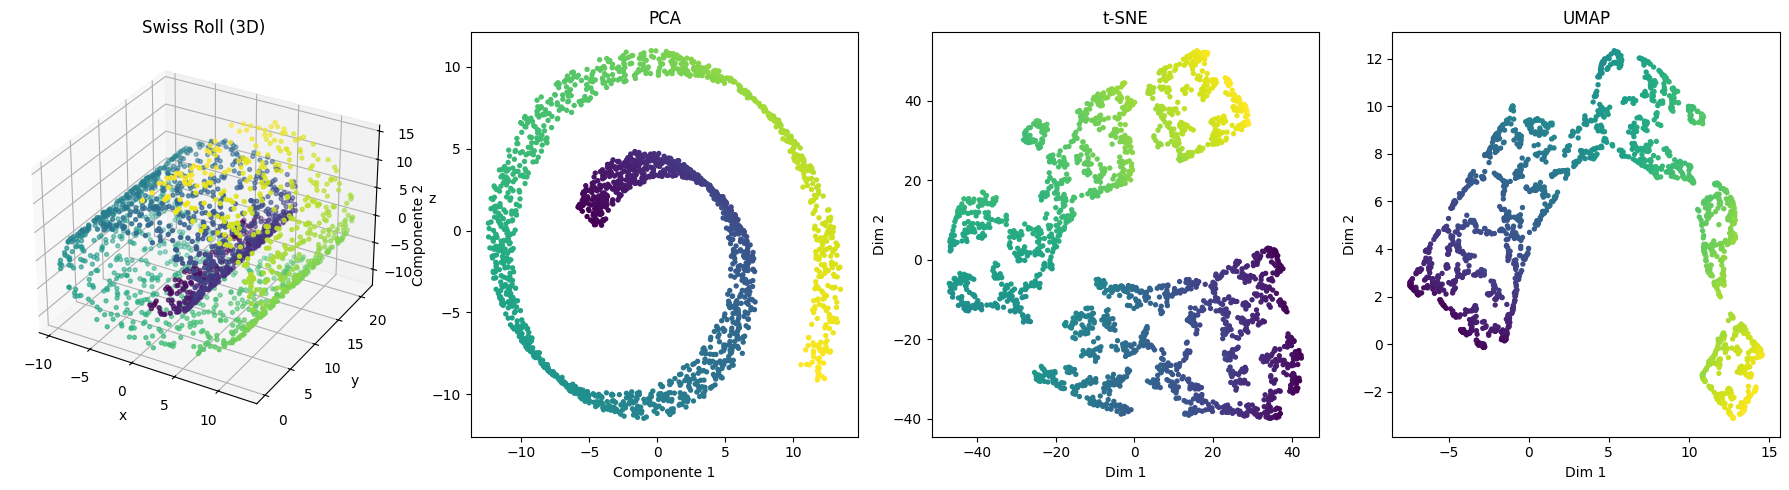

In [7]:
fig = plt.figure(figsize=(18, 5))

ax1 = fig.add_subplot(1, 4, 1, projection="3d")
ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c=t, s=8)
ax1.set_title("Swiss Roll (3D)")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")

ax2 = fig.add_subplot(1, 4, 2)
ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=t, s=8)
ax2.set_title("PCA")
ax2.set_xlabel("Componente 1")
ax2.set_ylabel("Componente 2")

ax3 = fig.add_subplot(1, 4, 3)
ax3.scatter(X_tsne[:, 0], X_tsne[:, 1], c=t, s=8)
ax3.set_title("t-SNE")
ax3.set_xlabel("Dim 1")
ax3.set_ylabel("Dim 2")

ax4 = fig.add_subplot(1, 4, 4)
ax4.scatter(X_umap[:, 0], X_umap[:, 1], c=t, s=8)
ax4.set_title("UMAP")
ax4.set_xlabel("Dim 1")
ax4.set_ylabel("Dim 2")

plt.tight_layout()
plt.show()

# Digits

In [8]:
from sklearn.datasets import load_digits

digits = load_digits()
X = digits.data
y = digits.target

# Estandarización
X_std = StandardScaler().fit_transform(X)

In [9]:
X_pca = PCA(n_components=2).fit_transform(X_std)


In [10]:
X_tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=42
).fit_transform(X_std)

In [11]:
X_umap = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
).fit_transform(X_std)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/tmp/ipykernel_313/74876022.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


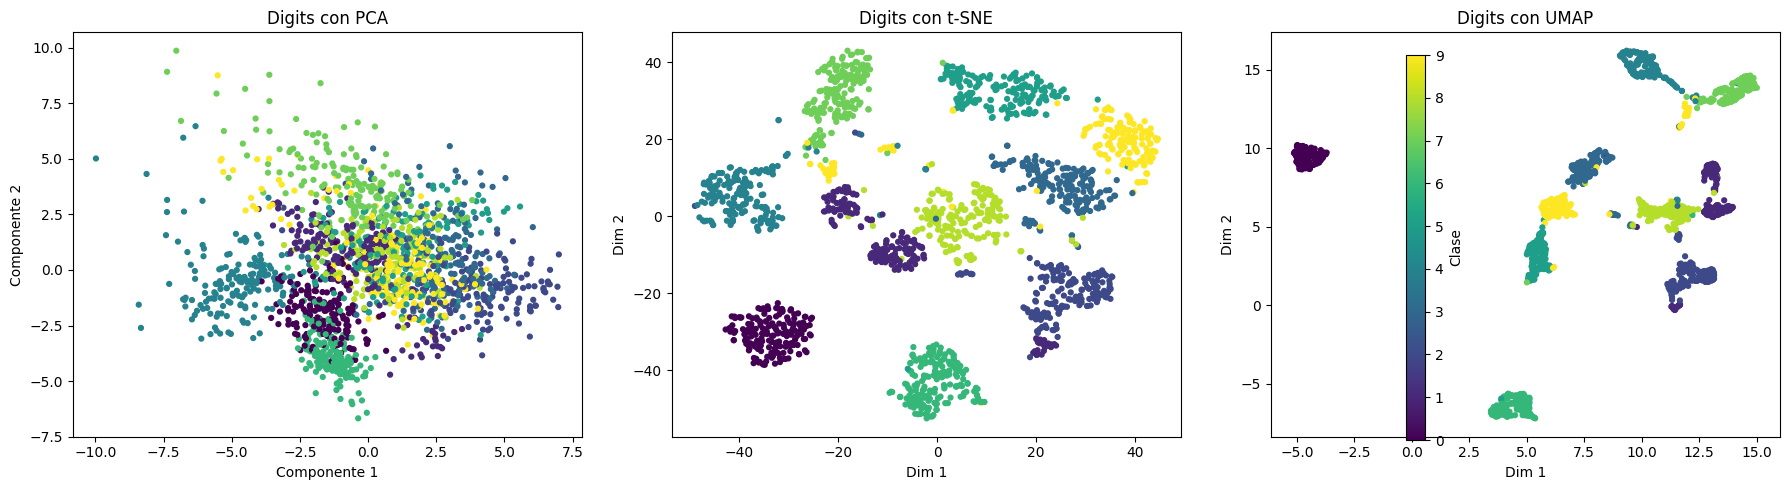

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=12)
axes[0].set_title("Digits con PCA")
axes[0].set_xlabel("Componente 1")
axes[0].set_ylabel("Componente 2")

axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, s=12)
axes[1].set_title("Digits con t-SNE")
axes[1].set_xlabel("Dim 1")
axes[1].set_ylabel("Dim 2")

axes[2].scatter(X_umap[:, 0], X_umap[:, 1], c=y, s=12)
axes[2].set_title("Digits con UMAP")
axes[2].set_xlabel("Dim 1")
axes[2].set_ylabel("Dim 2")

fig.colorbar(scatter, ax=axes, label="Clase")
plt.tight_layout()
plt.show()

# t-SNE

In [13]:
from sklearn.datasets import load_digits

In [14]:
digits = load_digits()
X = StandardScaler().fit_transform(digits.data)
y = digits.target

In [15]:
perplexities = [5, 30, 80]

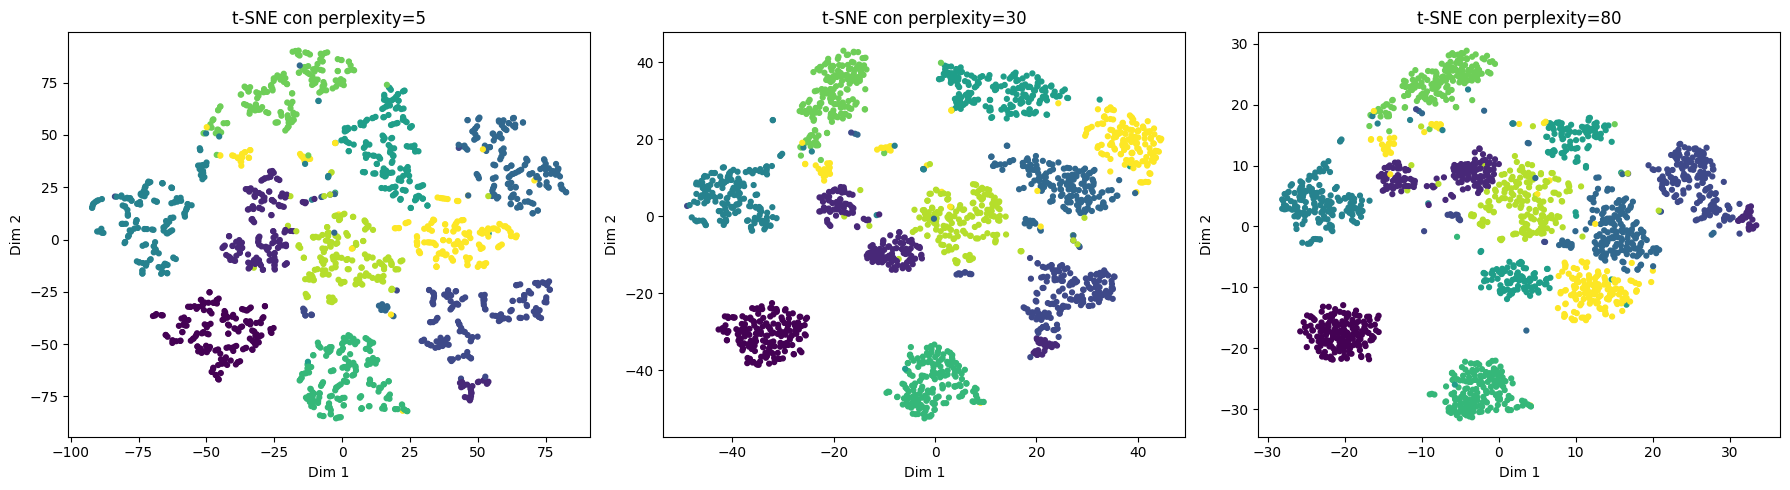

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, p in zip(axes, perplexities):
    X_tsne = TSNE(
        n_components=2,
        perplexity=p,
        init="pca",
        learning_rate="auto",
        random_state=42
    ).fit_transform(X)

    ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, s=12)
    ax.set_title(f"t-SNE con perplexity={p}")
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")

plt.tight_layout()
plt.show()

# UMAP

In [17]:
digits = load_digits()
X = StandardScaler().fit_transform(digits.data)
y = digits.target

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


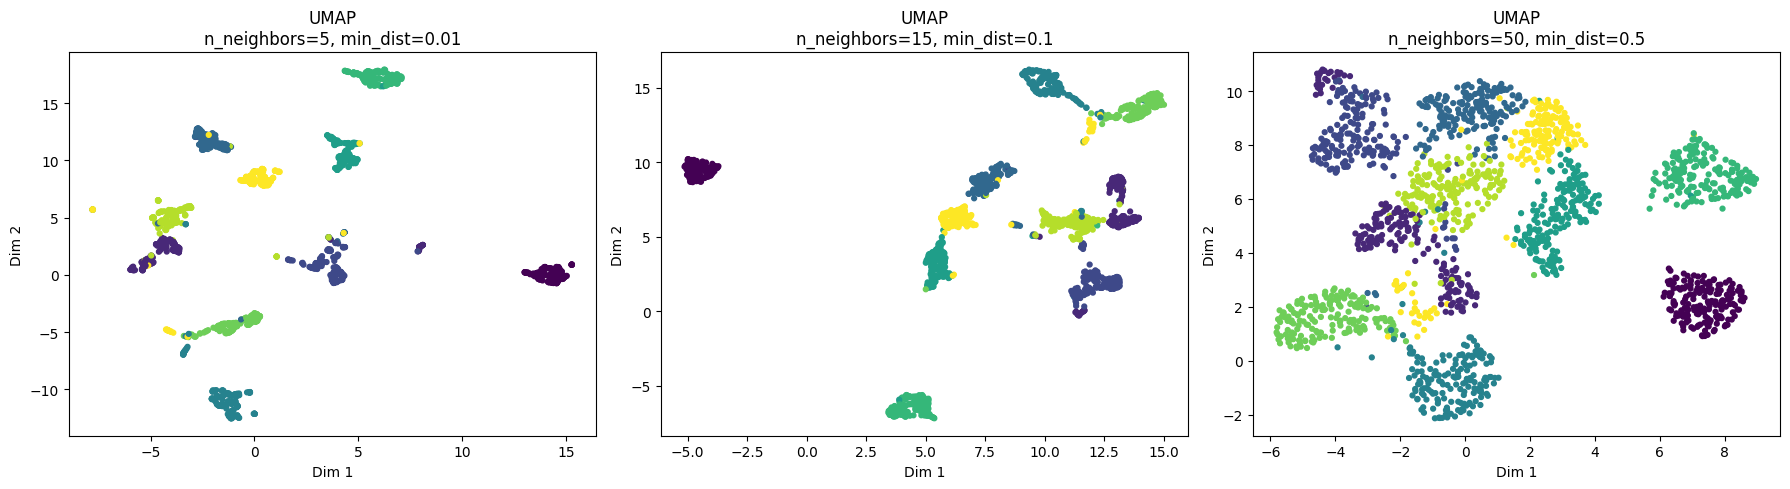

In [18]:
configs = [
    {"n_neighbors": 5, "min_dist": 0.01},
    {"n_neighbors": 15, "min_dist": 0.1},
    {"n_neighbors": 50, "min_dist": 0.5},
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, cfg in zip(axes, configs):
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=cfg["n_neighbors"],
        min_dist=cfg["min_dist"],
        random_state=42
    )
    X_umap = reducer.fit_transform(X)

    ax.scatter(X_umap[:, 0], X_umap[:, 1], c=y, s=12)
    ax.set_title(
        f'UMAP\nn_neighbors={cfg["n_neighbors"]}, min_dist={cfg["min_dist"]}'
    )
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")

plt.tight_layout()
plt.show()

In [21]:
from tensorflow.keras.datasets import fashion_mnist
import numpy as np

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

X = np.concatenate([X_train, X_test], axis=0)
y = np.concatenate([y_train, y_test], axis=0)

X = X.reshape(X.shape[0], -1)

print(X.shape)
print(y.shape)


(70000, 784)
(70000,)
